In [1]:
import os
import sys
import random
import optuna
import numpy as np
import pandas as pd
from dotenv import load_dotenv

sys.path.append("..")
from feature_engineering import time_based_train_test_split, get_return, round_to_step, get_mask, add_week_column, objective, get_best_features, get_feature_bins_map
from etl_pipeline_local import get_multigoal_24_table

sys.path.append("../..")
from strategies.strategies_utils import analyze_strategies, get_best_strategies

from utils import trial_key, run_one_study
pd.set_option('display.max_columns', None)
optuna.logging.set_verbosity(optuna.logging.WARN)

load_dotenv()

True

In [2]:
# TODO: far scegliere a Optuna se tenere o meno una variabile
# TODO: aggiungere early stopping
# TODO: perfezionare funzione di costo per tradeoff roi medio e quantità di partite considerate
# TODO: analisi  univariata KPI più promettenti (Optional)

# 1. Load Data

In [2]:
# Bet setup
target_col = "multigoal_24"
odds_col: str = "multigoal_24_odds"

# Load data
df_loaded = get_multigoal_24_table()
df_loaded = df_loaded.sort_values('time').reset_index(drop=True)
df = df_loaded.copy()


# Feature Engineering
df[odds_col] = 1.53
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x[odds_col]), axis=1).copy()
df["week"] = add_week_column(df)
df["chance1x2_xg_diff"] = abs(df["chance1x2_xg_home"] - df["chance1x2_xg_away"])

# Train/test split
df_train, df_test = time_based_train_test_split(df=df, time_col="time", train_frac=0.8)

# Feature acquisition
chance_features = list(df.filter(like="chance").columns)
goalNoGoal_features = list(df.filter(like="goalNoGoal").columns)
underOver_features = list(df.filter(like="underOver").columns)
evaluation_features = list(df.filter(like="evaluation").columns)
features_tot = chance_features + goalNoGoal_features + underOver_features + evaluation_features # goalNoGoal_features + underOver_features + evaluation_features

## 2. Feature Selection

In [3]:
# Define the feature selection raw search
objective_hyperparameters = {
    "n_trials": 500, # 500 - 1000
    "n_studies": 5, # 50
    "min_obs": 100, 
    "lambda": 1, # 0.5, 1, 2
    "tpe_sampler": 
        {
            "n_startup_trials": 10, # 100, # 10 - 30 per search space semplici, 50 100+ per seearch space con molti minimi
            "n_ei_candidates": 24, #128 # 24 default, problemi difficili: 64 o 128
        }
}

feature_rank = get_best_features(df=df_train, features=features_tot, objective_hyperparameters=objective_hyperparameters)

  9%|▉         | 12/132 [02:50<30:43, 15.36s/it]/home/maicolnicolini/code/bet-master-analytics/src/models/multigoal_24/../feature_engineering.py:503: UserWarning: The distribution is specified by [1.2000000000000002, 15.400000000000002] and step=0.2, but the range is not divisible by `step`. It will be replaced with [1.2000000000000002, 15.4].
  feat_min = trial.suggest_float(
/home/maicolnicolini/code/bet-master-analytics/src/models/multigoal_24/../feature_engineering.py:509: UserWarning: The distribution is specified by [1.2000000000000002, 15.600000000000001] and step=0.2, but the range is not divisible by `step`. It will be replaced with [1.2000000000000002, 15.6].
  feat_max = trial.suggest_float(
 12%|█▏        | 16/132 [03:52<29:35, 15.30s/it]/home/maicolnicolini/code/bet-master-analytics/src/models/multigoal_24/../feature_engineering.py:503: UserWarning: The distribution is specified by [2.4000000000000004, 12.8] and step=0.2, but the range is not divisible by `step`. It will b

In [6]:
# Retrieve feature_bins_map draft
threshold = feature_rank['score'].quantile(0.9)
top_features = feature_rank[feature_rank['score'] >= threshold]['feature'].tolist()
feature_bins_map = get_feature_bins_map(df_train, top_features)
feature_bins_map

{'chance1x2_quote_current1': 1,
 'chance1x2_bookkeeping_p1': 5,
 'chance1x2_quote_real1': 0.2,
 'evaluation_valMetrica': None,
 'chance1x2_bookkeeping_p2': 5,
 'chance1x2_chance_p2': 5,
 'chance1x2_chance_p1x': 5,
 'goalNoGoal_quote_diffRealCurrNG': 5,
 'chance1x2_quote_diffRealCurr2': 5,
 'chance1x2_bookkeeping_px': 1,
 'chance1x2_quote_initial1': 0.2,
 'chance1x2_xg_total': 0.2,
 'chance1x2_flashback_pHtx': 1,
 'chance1x2_flashback_p2': 5}

## 2. Define Parameters

In [12]:
# Define features and relative step

feature_bins_map = {
    'chance1x2_quote_current1': 1,
    'chance1x2_bookkeeping_p1': 5,
    'chance1x2_quote_real1': 0.2,
    'evaluation_valMetrica': None,
    'chance1x2_bookkeeping_p2': 5,
    # 'chance1x2_chance_p2': 5,
    'chance1x2_chance_p1x': 5,
    # 'goalNoGoal_quote_diffRealCurrNG': 5,
    # 'chance1x2_quote_diffRealCurr2': 5,
    # 'chance1x2_bookkeeping_px': 1,
    # 'chance1x2_quote_initial1': 0.2,
    # 'chance1x2_xg_total': 0.2,
    # 'chance1x2_flashback_pHtx': 1,
    # 'chance1x2_flashback_p2': 5
 }

objective_hyperparameters = {
    "n_trials": 500, # 500 - 1000
    "n_studies": 1, # 50
    "min_obs": 100, 
    "lambda": 1, # 0.5, 1, 2
    "tpe_sampler": 
    {
        "n_startup_trials": 100, # 10 - 30 per search space semplici, 50 100+ per seearch space con molti minimi
        "n_ei_candidates": 128 # 24 default, problemi difficili: 64 o 128
    }
}


# Create the binned dataframe
df_train_binned = df_train.copy()

for feat, step in feature_bins_map.items():
    df_train_binned[feat] = [round_to_step(x, step) for x in df_train_binned[feat]]

    if isinstance(step, int):
        df_train_binned[feat] = df_train_binned[feat].astype("Int64")

print("SEARCH SPACE\n")
for feat in feature_bins_map.keys():
    space = df_train_binned[feat].sort_values(ascending=True).unique()
    print(f"Feature: {feat}")
    print(f"Search space: {space}")
    print("\n")

SEARCH SPACE

Feature: chance1x2_quote_current1
Search space: <IntegerArray>
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 19]
Length: 15, dtype: Int64


Feature: chance1x2_bookkeeping_p1
Search space: <IntegerArray>
[5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90]
Length: 18, dtype: Int64


Feature: chance1x2_quote_real1
Search space: [ 1.2  1.4  1.6  1.8  2.   2.2  2.4  2.6  2.8  3.   3.2  3.4  3.6  3.8
  4.   4.2  4.4  4.6  4.8  5.   5.2  5.4  5.6  5.8  6.   6.2  6.4  6.6
  6.8  7.   7.2  7.4  7.6  7.8  8.   8.2  8.4  8.6  8.8  9.   9.2  9.4
  9.8 10.  10.2 10.6 10.8 11.  11.8 12.  12.2 13.2 13.8 14.2 15.  15.6]


Feature: evaluation_valMetrica
Search space: ['114521' '147930' '221599' '225586' '354214' '398418' '494608' '757193'
 '<NA>']


Feature: chance1x2_bookkeeping_p2
Search space: <IntegerArray>
[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85]
Length: 18, dtype: Int64


Feature: chance1x2_chance_p1x
Search space: <IntegerArray>
[

## 3. Optimize

In [13]:
optuna.logging.set_verbosity(optuna.logging.INFO)

# Generate random seeds
seeds = [random.randint(0, 2**32 - 1) for _ in range(objective_hyperparameters["n_studies"])]
studies = [
    run_one_study(
        seed=s, 
        objective_hyperparameters=objective_hyperparameters, 
        objective=objective,
        feature_bins_map=feature_bins_map, 
        df_binned=df_train_binned
        ) 
        for s in seeds]

all_trials = []
for study in studies:
    all_trials.extend(
        [t for t in study.trials if t.value is not None and t.state.name == "COMPLETE"]
    )

top_trials = sorted(all_trials, key=lambda t: -t.value)
best_trials = top_trials[:10]
print(best_trials)

[I 2026-04-22 18:19:54,506] A new study created in memory with name: no-name-fece63f1-927f-4f61-8b79-4b733fb1dc8b
[I 2026-04-22 18:19:54,510] Trial 0 pruned. 
[I 2026-04-22 18:19:54,512] Trial 1 pruned. 
[I 2026-04-22 18:19:54,513] Trial 2 pruned. 
[I 2026-04-22 18:19:54,516] Trial 3 pruned. 
[I 2026-04-22 18:19:54,517] Trial 4 pruned. 
[I 2026-04-22 18:19:54,520] Trial 5 pruned. 
[I 2026-04-22 18:19:54,522] Trial 6 pruned. 
[I 2026-04-22 18:19:54,523] Trial 7 pruned. 
/home/maicolnicolini/code/bet-master-analytics/src/models/multigoal_24/../feature_engineering.py:321: UserWarning: The distribution is specified by [1.2000000000000002, 15.400000000000002] and step=0.2, but the range is not divisible by `step`. It will be replaced with [1.2000000000000002, 15.4].
  feat_min = trial.suggest_float(
/home/maicolnicolini/code/bet-master-analytics/src/models/multigoal_24/../feature_engineering.py:327: UserWarning: The distribution is specified by [1.2000000000000002, 15.600000000000001] and s

[FrozenTrial(number=42, state=<TrialState.COMPLETE: 1>, values=[-0.8792881632093612], datetime_start=datetime.datetime(2026, 4, 22, 18, 19, 54, 622256), datetime_complete=datetime.datetime(2026, 4, 22, 18, 19, 54, 631661), params={'chance1x2_quote_current1_use_min': False, 'chance1x2_quote_current1_use_max': True, 'use_chance1x2_quote_current1': True, 'chance1x2_quote_current1_min': 3, 'chance1x2_quote_current1_max': 19, 'chance1x2_bookkeeping_p1_use_min': False, 'chance1x2_bookkeeping_p1_use_max': True, 'use_chance1x2_bookkeeping_p1': True, 'chance1x2_bookkeeping_p1_min': 40, 'chance1x2_bookkeeping_p1_max': 75, 'chance1x2_quote_real1_use_min': True, 'chance1x2_quote_real1_use_max': False, 'use_chance1x2_quote_real1': False, 'chance1x2_quote_real1_min': 7.000000000000001, 'chance1x2_quote_real1_max': 11.8, 'evaluation_valMetrica_cat_idx': 225, 'use_evaluation_valMetrica': False, 'chance1x2_bookkeeping_p2_use_min': True, 'chance1x2_bookkeeping_p2_use_max': False, 'use_chance1x2_bookkeep

## 4. Evaluate

In [14]:
# Create the test binned dataframe
return_threshold = -3.
df_test_binned = df_test.copy()

for feat, step in feature_bins_map.items():
    df_test_binned[feat] = [round_to_step(x, step) for x in df_test_binned[feat]]

    if isinstance(step, int):
        df_test_binned[feat] = df_test_binned[feat].astype("Int64")

# Get the resulting dataframes
for i, trial in enumerate(best_trials):
    params_dict = best_trials[i].user_attrs["params_dict"]

    train_mask = get_mask(df_train_binned, params_dict)
    test_mask = get_mask(df_test_binned, params_dict)

    df_train_filtered = df_train_binned[train_mask]
    df_test_filtered = df_test_binned[test_mask]

    df = pd.concat([df_train_filtered, df_test_filtered], axis=0)
    min_return = df.groupby('week')['return'].sum().min()
    max_return = df.groupby('week')['return'].sum().max()

    if min_return >= return_threshold:
        print(f"Trial no. {i}")
        print(f"Min return {min_return}")
        print(f"Max return {max_return}")
        print(f"Score {trial.value}")
        print("\n")

Trial no. 0
Min return -2.94
Max return 2.6500000000000004
Score -0.8792881632093612


Trial no. 1
Min return -2.4699999999999998
Max return 2.6500000000000004
Score -1.2961660608444825


Trial no. 2
Min return -2.4699999999999998
Max return 2.6500000000000004
Score -1.2961660608444825


Trial no. 3
Min return -2.4699999999999998
Max return 2.6500000000000004
Score -1.2961660608444825


Trial no. 4
Min return -2.4699999999999998
Max return 2.6500000000000004
Score -1.2961660608444825


Trial no. 5
Min return -2.4699999999999998
Max return 2.6500000000000004
Score -1.2961660608444825


Trial no. 6
Min return -2.4699999999999998
Max return 2.6500000000000004
Score -1.2961660608444825


Trial no. 7
Min return -2.4699999999999998
Max return 2.6500000000000004
Score -1.2961660608444825


Trial no. 8
Min return -2.4699999999999998
Max return 2.6500000000000004
Score -1.2961660608444825


Trial no. 9
Min return -2.4699999999999998
Max return 2.6500000000000004
Score -1.2961660608444825




Mean Train ROI: 0.061129032258064576
Train Accuracy: 0.7 (86/124)
Mean Test ROI: -0.1585
Test Accuracy: 0.6 (11/20)


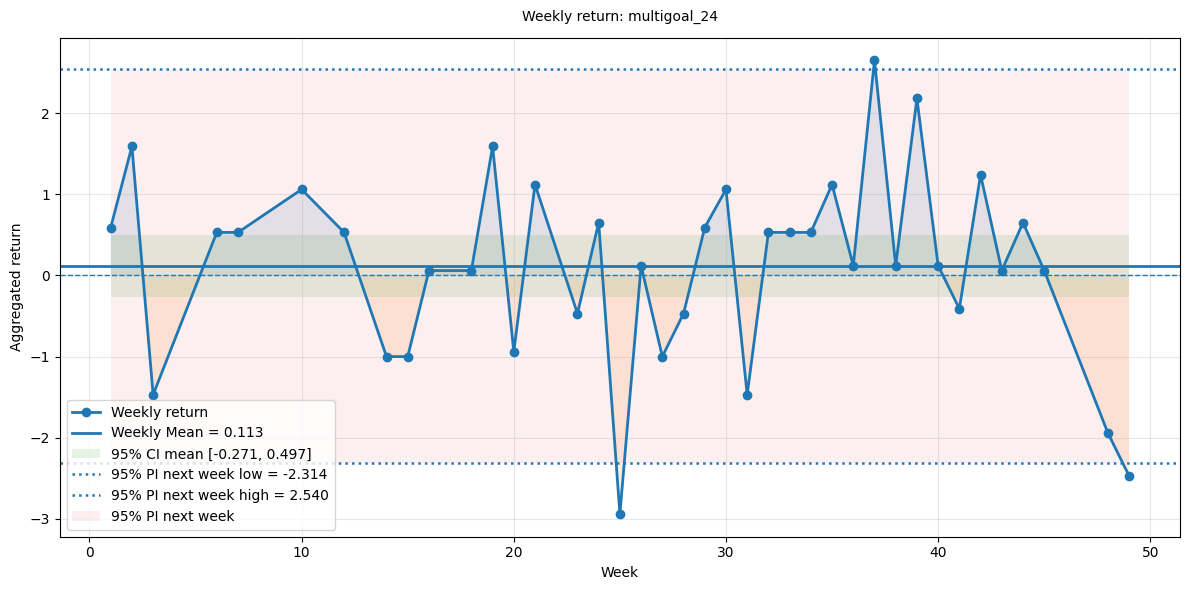

In [15]:
best_score_idx = 0

params_dict = best_trials[best_score_idx].user_attrs["params_dict"]

train_mask = get_mask(df_train_binned, params_dict)
test_mask = get_mask(df_test_binned, params_dict)

df_train_filtered = df_train_binned[train_mask]
df_test_filtered = df_test_binned[test_mask]


mean_roi = df_train_filtered["return"].mean()
right = df_train_filtered[target_col].sum()  
total = df_train_filtered.shape[0]

accuracy = np.round((right / total), 1)
print(f"Mean Train ROI: {mean_roi}")
print(f"Train Accuracy: {accuracy} ({right}/{total})")


mean_roi = df_test_filtered["return"].mean()
right = df_test_filtered[target_col].sum()  
total = df_test_filtered.shape[0]

accuracy = np.round((right / total), 1)
print(f"Mean Test ROI: {mean_roi}")
print(f"Test Accuracy: {accuracy} ({right}/{total})")


df_tot_filtered = pd.concat([df_train_filtered, df_test_filtered], axis=0).reset_index(drop=True).rename(columns={target_col: "result", "time": "date"})
df_tot_filtered = df_tot_filtered.sort_values(by="date", ascending=False)
 
df_tot_filtered["strategy"] = target_col

weekly_return, stats = analyze_strategies(df_tot_filtered, strategies=[target_col], print_pi=True)

In [20]:
# Get Stats
weeks = stats["n_weeks"]
total_weeks = max(df["week"])

print(f"No. of weeks covered: {weeks}/{total_weeks} ({np.round((weeks/total_weeks), 2)})")
weekly_stats = get_best_strategies(df_tot_filtered).iloc[0].to_dict()
weekly_stats["weeks_covered"] = np.round((weeks/total_weeks), 2)

get_best_strategies(df_tot_filtered)

No. of weeks covered: 38/45 (0.84)


,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
multigoal_24,-1.20,1.04,2.71,2.45,122,0.33


## 5. Save best Trials

In [ ]:
# Save best trials 
trial_to_save = best_trials[best_score_idx]

trial_to_save.set_user_attr("feature_bins_map", feature_bins_map)
trial_to_save.set_user_attr("weekly_stats", weekly_stats) 

study = optuna.create_study(
    study_name=f"{target_col}_aggregated_study",
    storage=os.getenv("OPTUNA_STORAGE"),
    direction="maximize",   
    load_if_exists=True,
)

existing = {trial_key(t) for t in study.trials if t.value is not None}

# esempio: best_frozen_trials = [study_seed_1.best_trial, study_seed_2.best_trial, ...]
new_best_trials = [
    t for t in [trial_to_save]
    if trial_key(t) not in existing
]

if new_best_trials:
    study.add_trials(new_best_trials)

print("Aggiunti:", len(new_best_trials))
print("Totale trial archiviati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

[I 2026-04-03 16:22:58,327] A new study created in RDB with name: over_15_aggregated_study


Aggiunti: 1
Totale trial archiviati: 1
Best assoluto: 2.428976876168547 {'underOver_chance_over15_use_min': True, 'underOver_chance_over15_use_max': True, 'underOver_chance_over15_min': 60, 'underOver_chance_over15_max': 90, 'underOver_comparison_affini_use_min': False, 'underOver_comparison_affini_use_max': True, 'underOver_comparison_affini_min': 3000, 'underOver_comparison_affini_max': 16000, 'underOver_comparison_flashback_use_min': False, 'underOver_comparison_flashback_use_max': True, 'underOver_comparison_flashback_min': 6000, 'underOver_comparison_flashback_max': 15000, 'underOver_flashback_over15_include_missing': False, 'underOver_flashback_over15_use_min': True, 'underOver_flashback_over15_use_max': False, 'underOver_flashback_over15_min': 76, 'underOver_flashback_over15_max': 92, 'evaluation_valUnderOver_cat_idx': 47}
